# Module 0. Observing the Earth

In this module, we'll explore how astronomers study exoplanets using our knowledge of our home world, Earth! 

## Learning goals: 
- Gain a conceptual understanding of flux, proper motion, and planetary transits
- Compare and contrast the light curves of a star that lacks a transiting plant and a star that possesses a transiting planet
- Explore how the transit method of exoplanet discovery operates

First, let's install our dependencies. We'll need this for the rest of the modules as well. 

In [1]:
import setup as s
from setup import * 

Installing dependencies...
Processing /home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work (from -r requirements.txt (line 1))
Done!


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/System/Volumes/Data/home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work'



Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


Now, let's imagine you're another intelligent life form on an alien world looking for signs of life. After staring at a particular star for many days, you begin to notice periodic dips in the star's <b>lightcurve</b> every 365 days (let's pretend a day on your planet is equivalent to one Earth day). You speculate that these dips are the result of a planet passing in front of the star as present the following model:

<figure>
  <img src="helpful_figures/alien_earth_model.gif" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>An animation of the dynamics of your orbit and the orbit of the planet you believe you're observing (Earth!). </a> 
  </p>
  </div>
</figure>

However, you're told that these periodic dips are simply a result of the <b>proper motion </b> of your target star. <span style = "color: red" > How can you prove that they're not? </span>

You decide to conduct a study of several other stars within a few parsecs of you to prove that this star is exhibiting odd behavior. You investigate 5 stars that lack the periodic dips at 365 days that your other target star possesses. However, you do notice that these stars <b>and</b> your original target star seem to oscillate very slightly in the sky. You term this oscillation <b>proper motion</b> and record it in arcseconds. Additionally, you record the distance each star is from you and the x and y coordinates of each star (in your own coordinate system). Load in the following file to recover these data points for each star.

In [2]:
your_data = ascii.read("stellar_observations.csv")

With this data, let's see if we can reconstruct the <b>lightcurves</b> you would have seen.

In [3]:
# We'll start by modeling the orbit of your home world first. 

# Define the distance your planet is from your host star in parsecs 
R_orbit = 1E-6 # pc 
# Define a year on your planet in terms of Earth days 
T = 200 # days 

# Let's say your observations of these stars were 30 days each 
time = np.linspace(0, 29,30)

In [4]:
# this function, defined in setup.py, gives us a model for a circularly orbiting planet 
my_orbit = s.orbit(R_orbit, T, len(time))

Now, let's model the motion of the star you're observing. To do this, we need to convert the "wiggling" of the star that you defined as "proper motion" into the transverse velocity of the star relative to you. Use some trigonometry and the following diagram to help you. 
<figure>
  <img src="helpful_figures/proper_motion.svg" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>A diagram relating distance, proper motion, and transverse velocity. </a> 
  </p>
  </div>
</figure>


In [5]:
def pm_to_vt(d, mu): 
    """
    Converting from proper motion (arcseconds per year) to transverse velocity (km/s)
    Distance should be in parsecs 
    """
    vt = 4.74 * d* mu
    return vt 

In [6]:
# Let's compute the transverse velocities for each star 
vt = pm_to_vt(your_data['distance'], your_data['proper_motion'])

# And obtain their positions over time according to the target_star function defined in setup.py
xpos,ypos = s.target_star(your_data['x'], your_data['y'], vt, time)

We can visualize this:

Text(0, 0.5, 'Y')

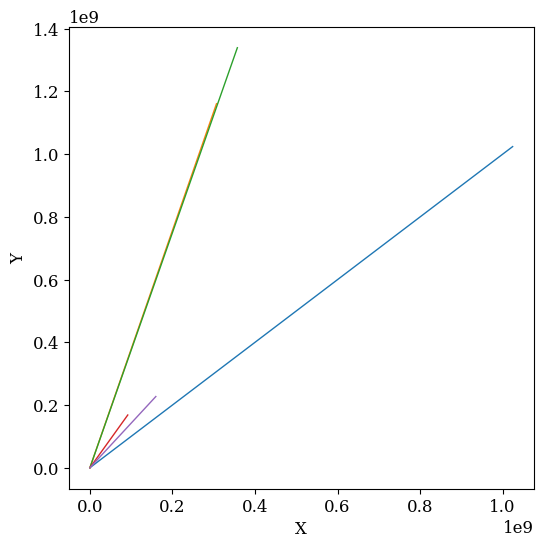

In [24]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(xpos, ypos)
ax.set_xlabel("X")
ax.set_ylabel("Y")

Awesome! We're seeing the stars move away from us, some more than others. This makes sense! 